# 🔗 Sparkov Fraud Dataset

Este notebook baixa e carrega o conjunto de dados **Sparkov Fraud Dataset** diretamente do Kaggle.

### 📊 Distribuição:
- Fraude: ~5.7%
- Legítimas: ~94.3%

### 🧠 Diagnóstico:
- Bem mais balanceado
- Features interpretáveis (category, amt, gender, merchant, city, job)
- Ideal para aprendizado de Machine Learning.

## 0. Configurações Globais e Importações

Célula dedicada a todas as bibliotecas necessárias para as rigorosas etapas de extração, validação, pré-processamento, rastreabilidade e reprodutibilidade requeridas para o pipeline.

In [1]:
# Instalando apenas as dependências estritamente necessárias
!pip install -q pandas numpy scikit-learn imbalanced-learn pyarrow

# ==========================================
# BIBLIOTECAS E CONFIGURAÇÕES GERAIS
# ==========================================

import os
import numpy as np
import pandas as pd

# Machine Learning - Validação, Divisão e Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, 
    RobustScaler, 
    MinMaxScaler, 
    OneHotEncoder, 
    OrdinalEncoder
)

# Desbalanceamento e Pipeline da Imbalanced-learn (MUITO IMPORTANTE!)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ==========================================
# CONFIGURAÇÕES DE REPRODUTIBILIDADE
# ==========================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)

print("✅ Bibliotecas minimalistas carregadas com sucesso! Seeds de reprodutibilidade fixadas.")

✅ Bibliotecas minimalistas carregadas com sucesso! Seeds de reprodutibilidade fixadas.


## 1. Carregar Dados com Pandas

Como já baixamos o arquivo pelo terminal, vamos carregar localmente o arquivo de treino `fraudTrain.csv`.

In [5]:
# Como o CSV original pesa >330MB (o GitHub bloqueia arquivos maiores de 100MB),
# nós salvamos/lemo-lo através de uma super compressão .parquet de alta performance!

file_csv = "fraudTrain.csv"
file_parquet = "fraudTrain_brotli.parquet"

if os.path.exists(file_csv):
    # Se você ainda tiver o CSV local sem compressão da extração:
    df = pd.read_csv(file_csv)
else:
    # Lendo o arquivo leve guardado em seu repositório no GitHub:
    df = pd.read_parquet(file_parquet)

# Exibir as primeiras linhas
display(df.head())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 2. Estrutura do Dataset (Features Interpretáveis)

Analisar tipos de dados, valores nulos e características descritivas: `category`, `amt`, `gender`, `merchant`, `city`, `job`.

In [6]:
# Verificar as informações gerais das colunas
df.info()

# Verificar a distribuição do alvo (fraude vs. legítimo)
print("\nDistribuição da classe (is_fraud):")
display(df['is_fraud'].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

## 3. Opcional: Carregamento Parcial (Para ambientes com pouca memória)

Caso o CSV (~500 MB) esteja forçando muito a memória RAM durante o treinamento, pode-se ler apenas uma pequena amostra das linhas:

In [ ]:
# Apenas amostra (100 mil linhas)
if os.path.exists("fraudTrain.csv"):
    df_sample = pd.read_csv("fraudTrain.csv", nrows=100000)
else:
    # Lendo apenas as primeiras 100k linhas usando parquet é imediato:
    df_sample = pd.read_parquet("fraudTrain_brotli.parquet").head(100000)

print(f"Linhas carregadas na amostra: {len(df_sample)}")

## Visualização dos Dados

In [7]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


## 4. Exploração de Dados (EDA)

Agora vamos entender o comportamento das fraudes analisando as features que já temos conhecimento da natureza. O objetivo desta etapa básica é responder a algumas perguntas fundamentais:

1. **Valores Nulos**: A base está íntegra ou existem dados faltando que precisaremos tratar?
2. **Valor da Transação (`amt`)**: As transações fraudulentas costumam ter valores mais altos ou mais baixos que as legítimas?
3. **Categorias de Maquininha/Compra (`category`)**: Certos tipos de estabelecimento sofrem mais com fraudes do que outros?

In [15]:
# 1. Checagem Rápida de Valores Ausentes (Nulos)
nulos = df.isnull().sum()
print("--- Valores Nulos Encontrados ---")
if nulos.sum() > 0:
    display(nulos[nulos > 0])
else:
    print("Ótima notícia! Nenhum valor nulo encontrado na base de dados.\n")

# 2. Análise Prática: Valor das Transações (`amt`) x Fraude
# Pergunta: As fraudes geralmente operam nas transações mais altas ou baixas?
print("--- Resumo Estatístico do Valor da Transação (`amt`) ---")
# Comparando pelo campo "is_fraud"
stats_amt = df.groupby('is_fraud')['amt'].describe()
display(stats_amt)


# 3. Perfis das Maquininhas/Lojas: Qual categoria atrai mais fraudadores?
print("\n--- Top 5 Categorias com as Maiores Taxas Relativas de Fraude (%) ---")
# Tiramos a média do is_fraud que por ser 0 (não fraude) e 1 (fraude) resulta na probabilidade ou taxa
taxa_fraude_cat = (df.groupby('category')['is_fraud'].mean() * 100).sort_values(ascending=False).head(5)
display(taxa_fraude_cat.to_frame("Taxa (%) de Fraude").round(2))

# 4. Correlação: Quais Variáveis Numéricas Mais Se Relacionam com a Fraude?
print("\n--- Correlação Numérica de Variáveis com 'is_fraud' ---")
# df.corr() calcula a correlação estatística de Pearson. numeric_only previne erros com variáveis de texto.
correlacoes = df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)

# Exclui a variável alvo da lista visual (pois a correlação dela com ela mesma é naturalmente 1.0)
correlacoes = correlacoes.drop('is_fraud', errors='ignore')

# Transforma em DataFrame para formatar visualmente as cores
df_corr = correlacoes.to_frame("Correlação (Pearson)")

# Gradiente: Tons quentes (vermelho) = relação positiva mais forte; Tons frios (azul) = relação negativa
display(df_corr.style.background_gradient(cmap='coolwarm', axis=0).format("{:.4f}"))

--- Valores Nulos Encontrados ---
Ótima notícia! Nenhum valor nulo encontrado na base de dados.

--- Resumo Estatístico do Valor da Transação (`amt`) ---


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.667110,154.007971,1.00,9.6100,47.280,82.540,28948.90
1,7506.0,531.320092,390.560070,1.06,245.6625,396.505,900.875,1376.04



--- Top 5 Categorias com as Maiores Taxas Relativas de Fraude (%) ---


,Taxa (%) de Fraude
category,
shopping_net,1.76
misc_net,1.45
grocery_pos,1.41
shopping_pos,0.72
gas_transport,0.47



--- Correlação Numérica de Variáveis com 'is_fraud' ---


,Correlação (Pearson)
amt,0.2194
hour_of_day,0.0138
age,0.0122
city_pop,0.0021
lat,0.0019
merch_lat,0.0017
merch_long,0.0017
long,0.0017
cc_num,-0.0010
zip,-0.0022


### 4.1 Entendendo Perfis através da Visualização 📊

A leitura estatística crua não ajuda tanto nos relatórios visuais. É interessante visualizarmos:
1. Um histograma (ou boxplot) do valor das transações. Para dados com muita variação (outliers), precisamos filtrar as compras legítimas extremas.
2. A Contagem simples de fraudes por categoria de gênero (`gender`). Quem "cai" mais? Homens ou mulheres?

--- Distribuição Relativa de Fraudes por Gênero ---


,gender,Total_Transacoes,Total_Fraudes,%_Fraude
0,F,709863,3735,0.53
1,M,586812,3771,0.64



--- Visualização da Taxa de Fraude por Gênero ---


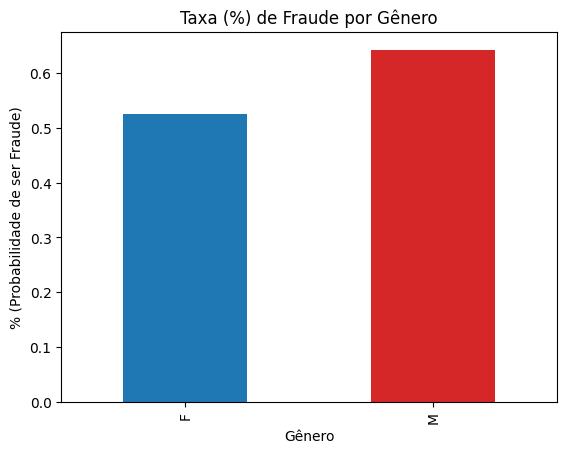

In [9]:
# Agrupar total de Fraudes e Totais de Transações por Sexo/Gênero (%)
df_gender = df.groupby('gender', as_index=False).agg(
    Total_Transacoes=('is_fraud', 'count'),
    Total_Fraudes=('is_fraud', 'sum')
)
df_gender['%_Fraude'] = (df_gender['Total_Fraudes'] / df_gender['Total_Transacoes']) * 100

print("--- Distribuição Relativa de Fraudes por Gênero ---")
display(df_gender.round(2))

# Geração de um gráfico de barras rápido pelo próprio Pandas
print("\n--- Visualização da Taxa de Fraude por Gênero ---")
ax = df_gender.plot(kind='bar', x='gender', y='%_Fraude', color=['#1f77b4', '#d62728'], legend=False, title="Taxa (%) de Fraude por Gênero")
ax.set_ylabel("% (Probabilidade de ser Fraude)");
ax.set_xlabel("Gênero");

### 4.2 Explorando Outras Dimensões: Estados, Profissões e Idade 🌎💼🕰️

Para termos uma visão holística, não podemos nos limitar apenas a valor e gênero. Nosso dataset possui colunas riquíssimas como localização (`state`), profissão (`job`) e data de nascimento (`dob`).

**O que vamos investigar agora:**
1. **Risco por Estado (`state`)**: Quais estados apresentam as maiores taxas de fraude?
2. **Engenharia de Features Básica (Idade)**: Vamos transformar a data de nascimento (`dob`) e a data da transação (`trans_date_trans_time`) na idade do cliente no momento da compra. Pessoas de qual faixa etária sofrem mais golpes?
3. **Ofícios (`job`)**: Existem profissões que são alvos mais frequentes de fraudadores?

In [14]:
# 1. Estados (`state`) com maiores taxas (probabilidade) de fraude
print("\n--- TOP 10 Estados com Maior Taxa de Fraude (%) ---")
# Agrupamos pelo estado, pegamos a média (pois a classe 1=fraude, 0=legítimo), e multiplicamos por 100
df_state = (df.groupby('state')['is_fraud'].mean() * 100).sort_values(ascending=False).head(10)
display(df_state.to_frame("Taxa (%) de Fraude").round(2))

# 2. Profissões (`job`) sofrendo maior índice de fraude
# (Para evitar distorções nas taxas de fraude de profissões com apenas 1 ou 2 transações em toda a base, filtramos contagens totais mínimas)
print("\n--- TOP 10 Profissões com Maior Probabilidade (%) de Fraudes ---")
jobs_agg = df.groupby('job').agg(Totais=('is_fraud', 'count'), Fraudes=('is_fraud', 'sum'))
jobs_agg['Taxa_Fraude_%'] = (jobs_agg['Fraudes'] / jobs_agg['Totais']) * 100
# Filtrar para profissões que aparecem no mínimo em 200 transações
jobs_relevantes = jobs_agg[jobs_agg['Totais'] > 200].sort_values(by='Taxa_Fraude_%', ascending=False).head(10)
display(jobs_relevantes.round(2))

# 3. Engenharia Rápida de Features (Criação de Coluna de Idade - `age`)
print("\n--- Taxa de Fraude por Faixa Etária ---")
# Garantindo que as colunas sejam formato Mês/Dia/Ano e convertendo pra objeto DateTime
df['dob_dt'] = pd.to_datetime(df['dob'])
df['trans_dt'] = pd.to_datetime(df['trans_date_trans_time'])

# Calcular a idade baseada nos anos de diferença
df['age'] = (df['trans_dt'] - df['dob_dt']).dt.days // 365

# Classificando em faixas etárias didáticas com pd.cut
bins = [0, 25, 40, 55, 70, 999] # cortes para faixas (0-25, 25-40, ...)
labels = ['Jovem (<25)', 'Adulto (25-40)', 'Meia-idade (41-55)', 'Sênior (56-70)', 'Idoso (>70)']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Mostrar resultados
age_stats = df.groupby('age_group')['is_fraud'].mean() * 100
display(age_stats.to_frame('Probabilidade de Fraude (%)').sort_values(by='Probabilidade de Fraude (%)', ascending=False).round(2))


--- TOP 10 Estados com Maior Taxa de Fraude (%) ---


,Taxa (%) de Fraude
state,
DE,100.00
RI,2.73
AK,1.70
NV,0.84
CO,0.81
OR,0.80
TN,0.80
NE,0.74
ME,0.72



--- TOP 10 Profissões com Maior Probabilidade (%) de Fraudes ---


,Totais,Fraudes,Taxa_Fraude_%
job,,,
Lawyer,540,28,5.19
TEFL teacher,533,22,4.13
Community development worker,536,22,4.10
Clinical cytogeneticist,508,18,3.54
Writer,504,15,2.98
"Geneticist, molecular",545,16,2.94
"Conservator, museum/gallery",514,15,2.92
Magazine journalist,533,14,2.63
Field trials officer,518,13,2.51



--- Taxa de Fraude por Faixa Etária ---


C:\Users\negre\AppData\Local\Temp\ipykernel_25304\1263401856.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('age_group')['is_fraud'].mean() * 100


,Probabilidade de Fraude (%)
age_group,
Idoso (>70),0.85
Sênior (56-70),0.69
Jovem (<25),0.63
Meia-idade (41-55),0.52
Adulto (25-40),0.47


### 4.3 A Regra do "Quando" e "Onde": Análise Temporal, População e Lojas 🕛🏙️🏪

Fraudadores possuem hábitos específicos. Nesta etapa, exploraremos:
1. **Padrões Temporais (Hora e Dia)**: A fraude acontece mais de madrugada ou durante o dia útil? (Usaremos a data da transação `trans_date_trans_time`).
2. **Tamanho das Cidades (`city_pop`)**: Existe alguma correlação entre ser atacado e morar em uma cidade pequena versus uma metrópole?
3. **Lojas Visadas (`merchant`)**: Há lojas (merchants) específicas que sofrem golpes com uma frequência assustadora?

--- Taxa de Fraude por Hora do Dia (%) ---


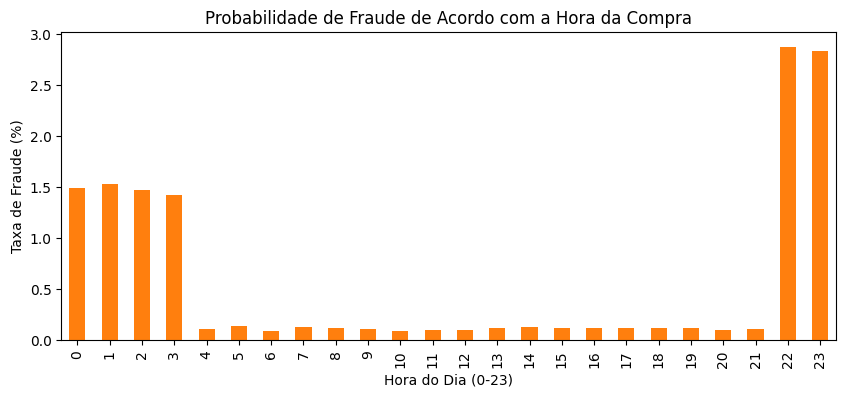


--- Fraudes vs Tamanho da Cidade do Titular ---


,Taxa (%) de Fraude
pop_group,
Grande (100k-1M),0.67
Metrópole (>1M),0.59
Pequena (<10k),0.57
Média (10k-100k),0.55



--- TOP 10 Lojas/Comerciantes (Merchant) Com as Maiores Taxas de Fraude ---


,Totais,Fraudes,Taxa_Fraude_%
merchant,,,
fraud_Kozey-Boehm,1866,48,2.57
"fraud_Herman, Treutel and Dickens",1300,33,2.54
fraud_Kerluke-Abshire,1838,41,2.23
fraud_Brown PLC,1176,26,2.21
fraud_Goyette Inc,1943,42,2.16
fraud_Terry-Huel,1996,43,2.15
fraud_Jast Ltd,1953,42,2.15
"fraud_Schmeler, Bashirian and Price",1968,41,2.08
fraud_Boyer-Reichert,1908,38,1.99


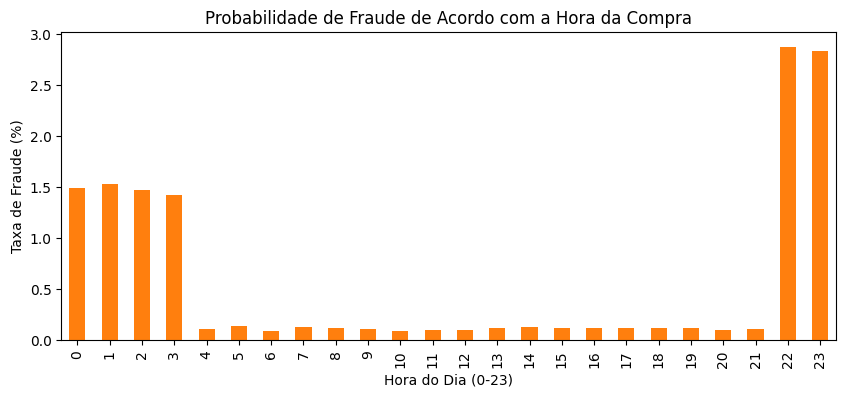

In [11]:
# 1. Padrões Temporais (Que horas e dias os fraudadores mais atacam?)
# A coluna `trans_dt` já foi extraída na etapa de Idade
df['hour_of_day'] = df['trans_dt'].dt.hour
df['day_of_week'] = df['trans_dt'].dt.day_name() # Segunda, Terça, etc.

print("--- Taxa de Fraude por Hora do Dia (%) ---")
hour_stats = (df.groupby('hour_of_day')['is_fraud'].mean() * 100).round(2)

# Gráfico para as Horas do Dia (Uma visualização clara de picos)
ax_hour = hour_stats.plot(kind='bar', figsize=(10, 4), color='#ff7f0e', title="Probabilidade de Fraude de Acordo com a Hora da Compra")
ax_hour.set_ylabel("Taxa de Fraude (%)")
ax_hour.set_xlabel("Hora do Dia (0-23)")
display(ax_hour.figure) # Força mostrar apenas a figura limpa


# 2. População da Cidade (city_pop) - Agrupando por Tamanho de Cidade
print("\n--- Fraudes vs Tamanho da Cidade do Titular ---")
bins_pop = [0, 10000, 100000, 1000000, 999999999]
labels_pop = ['Pequena (<10k)', 'Média (10k-100k)', 'Grande (100k-1M)', 'Metrópole (>1M)']
df['pop_group'] = pd.cut(df['city_pop'], bins=bins_pop, labels=labels_pop, right=False)

pop_stats = (df.groupby('pop_group', observed=True)['is_fraud'].mean() * 100).sort_values(ascending=False).round(2)
display(pop_stats.to_frame("Taxa (%) de Fraude"))


# 3. Lojas (Merchants) Mais Extremas
print("\n--- TOP 10 Lojas/Comerciantes (Merchant) Com as Maiores Taxas de Fraude ---")
# Novamente aplicamos filtro contra falsos positivos de poucas amostras. Ignoramos onde só houve 1 ou 2 compras totais.
merch_agg = df.groupby('merchant').agg(Totais=('is_fraud', 'count'), Fraudes=('is_fraud', 'sum'))
merch_agg['Taxa_Fraude_%'] = (merch_agg['Fraudes'] / merch_agg['Totais']) * 100

top_merchants = merch_agg[merch_agg['Totais'] > 50].sort_values(by='Taxa_Fraude_%', ascending=False).head(10)
display(top_merchants.round(2))

### 4.4 Cruzamento de Variáveis (Análise Multivariada) 🔀

Até agora vimos as categorias isoladamente. Mas o que acontece quando **combinamos** essas informações? Será que homens sofrem fraudes em categorias diferentes das mulheres? Ou será que os idosos são mais atacados em horários diferentes dos jovens?

Fazer essa correlação bivariada (avaliar duas features ao mesmo tempo frente à variável alvo de fraude) é uma das etapas mais reveladoras da Análise Exploratória.

Vamos cruzar:
1. **Gênero x Categoria da Compra**: Para investigar o perfil do ataque.
2. **Faixa Etária x Período do Dia**: Para investigar vulnerabilidades na rotina.

In [13]:
# 1. Cruzamento: Gênero vs Categoria de Compra
print("--- Taxa de Fraude (%): Gênero x Categoria de Compra ---")

# Criação de uma tabela dinâmica (Pivot Table) extraindo a média de fraudes por combinação
cross_gender_cat = pd.pivot_table(
    df, 
    values='is_fraud', 
    index='category', 
    columns='gender', 
    aggfunc=lambda x: np.mean(x) * 100
)

# Utilizando o 'style.background_gradient' do próprio Pandas para criar um Heatmap (Mapa de Calor) rápido
display(cross_gender_cat.style.background_gradient(cmap='Reds').format("{:.2f}%").set_caption("Tons mais escuros = Maior chance de fraude"))


# 2. Cruzamento: Faixa Etária vs Período do Dia
print("\n--- Taxa de Fraude (%): Faixa Etária x Período do Dia ---")

# Primeiro: Vamos categorizar as 24 horas em 4 turnos (Madrugada, Manhã, Tarde e Noite)
bins_hora = [0, 6, 12, 18, 24]
labels_hora = ['Madrugada (00-06)', 'Manhã (06-12)', 'Tarde (12-18)', 'Noite (18-24)']
df['periodo_dia'] = pd.cut(df['hour_of_day'], bins=bins_hora, labels=labels_hora, right=False)

# Criando a tabela cruzando as duas faixas recém criadas (idade e período)
cross_age_time = pd.pivot_table(
    df, 
    values='is_fraud', 
    index='age_group', 
    columns='periodo_dia', 
    aggfunc=lambda x: np.mean(x) * 100,
    observed=True  # Evita warns ao cruzar dados do tipo "Category"
)

# Renderizando com aspecto visual claro
display(cross_age_time.style.background_gradient(cmap='Oranges').format("{:.2f}%").set_caption("Tons mais escuros = Maior chance de fraude"))

--- Taxa de Fraude (%): Gênero x Categoria de Compra ---


gender,F,M
category,,
entertainment,0.30%,0.19%
food_dining,0.24%,0.08%
gas_transport,0.35%,0.62%
grocery_net,0.23%,0.38%
grocery_pos,1.15%,1.70%
health_fitness,0.25%,0.05%
home,0.28%,0.03%
kids_pets,0.30%,0.10%
misc_net,1.10%,1.89%



--- Taxa de Fraude (%): Faixa Etária x Período do Dia ---


periodo_dia,Madrugada (00-06),Manhã (06-12),Tarde (12-18),Noite (18-24)
age_group,,,,
Jovem (<25),2.36%,0.30%,0.07%,0.80%
Adulto (25-40),1.22%,0.12%,0.06%,0.70%
Meia-idade (41-55),0.97%,0.10%,0.10%,0.90%
Sênior (56-70),0.72%,0.09%,0.26%,1.78%
Idoso (>70),0.87%,0.07%,0.29%,2.30%


### 4.5 Evolução Avançada: Detectando "Smurfing / Carding" (Temporal + Densidade) 🚨

A análise original não diz o quão *camuflado* é o golpe. Para identificarmos o padrão onde golpistas rodam múltiplas aprovações para "Testar as Águas" com nível profissional (de mercado), incluímos componentes preditivos melhores:

1. **Limiar Data-Driven Mais Rigoroso (`Percentil 25 - Q1`)**: Para captarmos os rombos irrisórios verdadeiros, muito abaixo da nossa alta mediana.
2. **Avaliação Temporal (`Rajadas por Dia`)**: Isolando a "janela temporal" detectamos comportamentos bizarros de alta frequência em um único dia.
3. **Proporção e Densidade**: Transações normais estão servindo para esconder (camuflar) que tamanho de volume de transações criminosas?
4. **Baseline Comparativo**: Validação cruzando o comportamento lado a lado com **pacientes sadios** do dataset para evitar falsos positivos.

In [17]:
# 1. Definir "Baixo Valor" de forma rigída e matemática (P25 - Primeiro Quartil das Fraudes)
limite_p25 = df[df['is_fraud'] == 1]['amt'].quantile(0.25)
print(f"--- 🎯 Limiar Fino de Microfraude (P25): $ {limite_p25:.2f} ---")

# 2. Criar flags de comportamento individual por transação
df['is_micro_transacao'] = df['amt'] <= limite_p25
df['is_micro_fraude'] = (df['is_fraud'] == 1) & df['is_micro_transacao']

# 3. Componente Temporal: Construindo uma "Janela Temporal" de acompanhamento
# Cria coluna apenas com a Data nominal para agrupamento e rastreio de "rajadas diárias" 
df['data_compra'] = df['trans_dt'].dt.date

# 4. Primeiro Agrupamento: Calculando frequência de eventos POR DIA para cada cliente
perfil_diario = df.groupby(['cc_num', 'data_compra']).agg(
    Transacoes_No_Dia=('amt', 'count'),
    Micro_Transacoes_Dia=('is_micro_transacao', 'sum'),
    Total_Fraudes_Dia=('is_fraud', 'sum'),
    Micro_Fraudes_Dia=('is_micro_fraude', 'sum')
).reset_index()

# 5. Agregação Final: Perfil Completo de Cada Cliente + Baseline Sadio Envolvido no Pool
perfil_cliente = perfil_diario.groupby('cc_num').agg(
    Total_Transacoes=('Transacoes_No_Dia', 'sum'),
    Total_Micro_Transacoes=('Micro_Transacoes_Dia', 'sum'),
    Total_Geral_Fraudes=('Total_Fraudes_Dia', 'sum'),
    Total_Micro_Fraudes=('Micro_Fraudes_Dia', 'sum'),
    # Nova Feature Essencial Anômala e Temporal:
    Pico_Transacoes_Num_Unico_Dia=('Transacoes_No_Dia', 'max') 
)

# 6. Criando Taxas Interpretativas (Análise de Densidade/Camuflagem)
perfil_cliente['Densidade_Micro_Transacao_%'] = (perfil_cliente['Total_Micro_Transacoes'] / perfil_cliente['Total_Transacoes']) * 100

# Proporcional de "Micro Fraude" versus toda as 'Micro Transações Corriqueiras' do cliente (Evitando os dízimos onde count é zero)
perfil_cliente['Taxa_Criminal_Pequena_%'] = np.where(
    perfil_cliente['Total_Micro_Transacoes'] > 0,
    (perfil_cliente['Total_Micro_Fraudes'] / perfil_cliente['Total_Micro_Transacoes']) * 100,
    0
)

# 7. Modelo Mapeador (Algoritmo de Classificação por Regras com Presença Baseline)
def classificador_stealth(row):
    # Cliente Sadio (Testemunha/Baseline)
    if row['Total_Geral_Fraudes'] == 0:
        return '1. Baseline Limpos (Normais)'
    
    # Alta Densidade de microtransacao (> 20%) combando com um Burst/Rajada de uso temporal (> 3 num dia) + Presença de Micro Fraudes
    elif row['Total_Micro_Fraudes'] > 0 and row['Densidade_Micro_Transacao_%'] >= 10 and row['Pico_Transacoes_Num_Unico_Dia'] >= 4:
        return '3. 🚨 Carding Camuflado (Burst Alta Frequência)'
    
    # Sofre micro-fraudes isoladas, não configura camuflagem estruturada
    elif row['Total_Micro_Fraudes'] > 0:
        return '2. Fraude Pequena (Não camuflada fortemente)'
    
    # Perfil padrão de golpes grandes apenas
    else:
        return '4. Modus Operandi Clássico (Apenas Rombo Alto)'

perfil_cliente['Classificacao_Alvo'] = perfil_cliente.apply(classificador_stealth, axis=1)

# 8. Renderização do Painel Comparativo Evoluído!
print("\n--- 📊 Painel Anti-Fraude: Perfil Normal vs. Assinatura Smurfing ---")
painel_avancado = perfil_cliente.groupby('Classificacao_Alvo').agg(
    Contagem_Total_Clientes=('Total_Transacoes', 'count'),
    Media_Volume_Transacoes=('Total_Transacoes', 'mean'),
    Media_MAX_Rajada_Diaria=('Pico_Transacoes_Num_Unico_Dia', 'mean'), # Anomalia Temporal
    Taxa_Media_Micro_Transacao_Na_Fatura=('Densidade_Micro_Transacao_%', 'mean')
).round(2)

display(painel_avancado)

--- 🎯 Limiar Fino de Microfraude (P25): $ 245.66 ---

--- 📊 Painel Anti-Fraude: Perfil Normal vs. Assinatura Smurfing ---


,Contagem_Total_Clientes,Media_Volume_Transacoes,Media_MAX_Rajada_Diaria,Taxa_Media_Micro_Transacao_Na_Fatura
Classificacao_Alvo,,,,
1. Baseline Limpos (Normais),221,1447.29,11.81,97.37
2. Fraude Pequena (Não camuflada fortemente),6,12.00,7.17,8.43
3. 🚨 Carding Camuflado (Burst Alta Frequência),674,1319.01,11.61,90.39
4. Modus Operandi Clássico (Apenas Rombo Alto),82,1069.95,9.95,83.81


### 4.6 O Tamanho do Rombo: Distribuição das Fraudes por Montante 💰📉

Embora saibamos que as micro-fraudes acontecem para "testar" contas, qual é a representatividade delas no bolo total contra os grandes assaltos? 

Para ter o panorama exato da operação visualmente, separaremos todo o conjunto **criminoso** (apenas os casos confirmados) nestes 5 níveis de montante:
1. **Muito Baixo** (O típico "teste" stealth, menor que \$50)
2. **Baixo** (\$50 a \$200)
3. **Médio** (\$200 a \$500)
4. **Alto** (\$500 a \$1.000)
5. **Altíssimo** (Os grandes rombos acima de \$1.000)

--- 📊 Distribuição Textual das Fraudes por Nível de Valor ---


,Ocorrencias,% entre todas Fraudes
Nivel_Montante,,
1. Muito Baixo (< $50),1607,21.41
2. Baixo ($50 a $200),195,2.60
3. Médio ($200 a $500),2056,27.39
4. Alto ($500 a $1000),2698,35.94
5. Altíssimo (> $1000),950,12.66



--- 📈 Gráfico de Distribuição do Crime ---


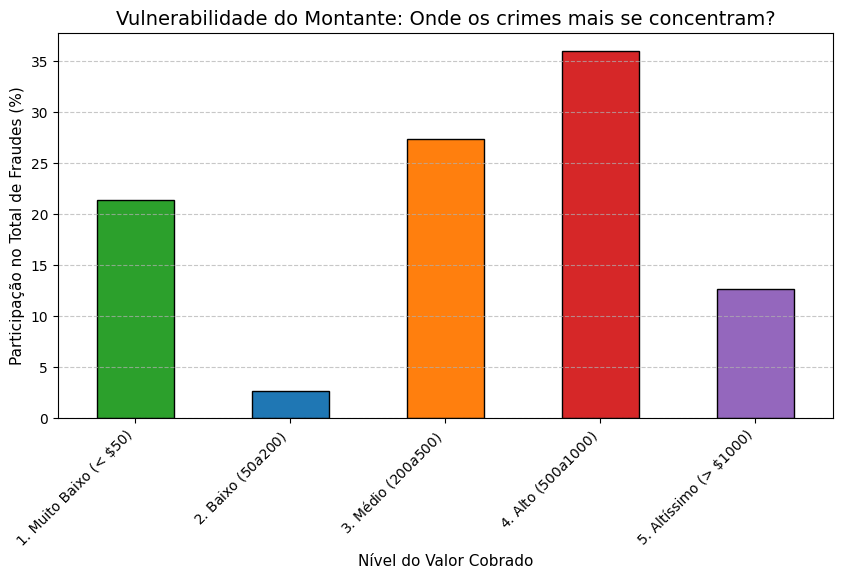

In [18]:
import matplotlib.pyplot as plt

# 1. Isolar apenas os dados de Fraudes
df_fraudes = df[df['is_fraud'] == 1].copy()

# 2. Categorização de faixas reais (Bins)
bins_montante = [0, 50, 200, 500, 1000, float('inf')]
labels_montante = [
    '1. Muito Baixo (< $50)', 
    '2. Baixo ($50 a $200)', 
    '3. Médio ($200 a $500)', 
    '4. Alto ($500 a $1000)', 
    '5. Altíssimo (> $1000)'
]

# Recortar a coluna 'amt' com base nos rótulos que definimos acima
df_fraudes['Nivel_Montante'] = pd.cut(df_fraudes['amt'], bins=bins_montante, labels=labels_montante, right=False)

# 3. Construção da Tabela (Ocorrências e Proporção/Porcentagem)
tabela_montante = df_fraudes.groupby('Nivel_Montante', observed=True).agg(
    Ocorrencias=('is_fraud', 'count')
)
# Calcular a representatividade matemática dentro do mundo do crime %
tabela_montante['% entre todas Fraudes'] = (tabela_montante['Ocorrencias'] / len(df_fraudes) * 100).round(2)

print("--- 📊 Distribuição Textual das Fraudes por Nível de Valor ---")
display(tabela_montante)


# 4. Construção do Gráfico (Para rápida interpretação visual)
print("\n--- 📈 Gráfico de Distribuição do Crime ---")
Cores = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd'] # Cores que mostram caloridade ou perigo progressivo
ax = tabela_montante['% entre todas Fraudes'].plot(kind='bar', figsize=(10, 5), color=Cores, edgecolor='black', linewidth=1)

# Estética de mercado para o plot
ax.set_title("Vulnerabilidade do Montante: Onde os crimes mais se concentram?", fontsize=14)
ax.set_ylabel("Participação no Total de Fraudes (%)", fontsize=11)
ax.set_xlabel("Nível do Valor Cobrado", fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotação com alinhamento 'Right' para ler melhor no eixo X
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Forçar exibição da imagem
display(ax.figure)
plt.close() # Limpar objeto da memória para manter o notebook leve